# 70/30 Mixed attacks + Augmentation — Expanded Dataset Training

**Aligned with:** `src/train_mixed_70_30.py`

**Split:** 70% of training images enter the *attacked* set (each bbox gets a **random** attack from `ATTACK_MAP`); 30% stay clean.

**Attacks (per bbox):** `tape`, `patch`, `heavy_occlusion`, `graffiti`, `illumination`

**Expansion:** Every image (clean or attacked) is saved again with Albumentations → ~2x dataset size.

**Training:** Fine-tune from `models/best.pt` (same as script default). Hyperparameters match the script unless you edit **Step 2**.

### Albumentations (all images)
- Horizontal flip, brightness/contrast, HSV, Gaussian blur, CLAHE, JPEG compression, random shadow

---

### Setup
1. `archive.zip` at project root; `models/best.pt` and project `data.yaml` present
2. GPU recommended
3. Run cells in order


In [1]:
!pip install ultralytics albumentations matplotlib pyyaml --quiet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import os

if os.path.exists('/content'):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass


In [3]:

import torch
print(f"Is GPU available? {torch.cuda.is_available()}")


Is GPU available? True


In [4]:

import zipfile
import os
from pathlib import Path

IS_COLAB = os.path.exists('/content') and os.access('/content', os.W_OK)

if IS_COLAB:
    ROOT_DIR = '/content'
else:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    root_candidate = next((p for p in candidates if (p / 'archive.zip').exists()), None)
    ROOT_DIR = str(root_candidate if root_candidate else cwd)

DATASETS_DIR = os.path.join(ROOT_DIR, 'datasets')
ARCHIVE_ZIP = os.path.join(ROOT_DIR, 'archive.zip')
ARCHIVE_DIR = os.path.join(DATASETS_DIR, 'archive')

if not os.path.exists(ARCHIVE_ZIP):
    raise FileNotFoundError(f"archive.zip not found at: {ARCHIVE_ZIP}")

os.makedirs(DATASETS_DIR, exist_ok=True)
with zipfile.ZipFile(ARCHIVE_ZIP, 'r') as zip_ref:
    zip_ref.extractall(ARCHIVE_DIR)

print('Dataset extracted.')
print(f'ROOT_DIR: {ROOT_DIR}')
print(f'ARCHIVE_DIR: {ARCHIVE_DIR}')


Dataset extracted.
ROOT_DIR: C:\Users\Karim\Desktop\Road-Sign-Detection-Model
ARCHIVE_DIR: C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive


## Step 1 — Attack functions (same as `train_mixed_70_30.py`)


In [5]:

import random
import shutil
import cv2
import os
import numpy as np
import albumentations as A


def apply_digital_tape(image, bbox, color=(50, 50, 50), thickness_ratio=0.2):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w / 2) * w)
    x2 = int((x_center + b_w / 2) * w)
    y1 = int((y_center - b_h / 2) * h)
    y2 = int((y_center + b_h / 2) * h)
    tape_h  = int((y2 - y1) * thickness_ratio)
    tape_y1 = int(y_center * h - tape_h / 2)
    tape_y2 = int(y_center * h + tape_h / 2)
    cv2.rectangle(image, (x1, tape_y1), (x2, tape_y2), color, -1)
    return image


def apply_adversarial_patch(image, bbox):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w / 4) * w)
    y1 = int((y_center - b_h / 4) * h)
    x2 = int((x_center + b_w / 4) * w)
    y2 = int((y_center + b_h / 4) * h)
    patch_h = max(1, y2 - y1)
    patch_w = max(1, x2 - x1)
    image[y1:y2, x1:x2] = np.random.randint(0, 255, (patch_h, patch_w, 3), dtype=np.uint8)
    return image


def apply_heavy_occlusion(image, bbox):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w * 0.4) * w)
    y1 = int((y_center - b_h * 0.4) * h)
    x2 = int((x_center + b_w * 0.4) * w)
    y2 = int((y_center + b_h * 0.4) * h)
    cv2.rectangle(image, (x1, y1), (x2, y2), (128, 128, 128), -1)
    return image


def apply_graffiti(image, bbox, num_elements=6):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w / 2) * w)
    y1 = int((y_center - b_h / 2) * h)
    x2 = int((x_center + b_w / 2) * w)
    y2 = int((y_center + b_h / 2) * h)
    sign_w = max(1, x2 - x1)
    sign_h = max(1, y2 - y1)

    def rand_point():
        return (int(np.random.uniform(x1, x2)), int(np.random.uniform(y1, y2)))

    def rand_color():
        hue = np.random.randint(0, 180)
        bgr = cv2.cvtColor(np.array([[[hue, 220, 200]]], dtype=np.uint8), cv2.COLOR_HSV2BGR)[0][0]
        return (int(bgr[0]), int(bgr[1]), int(bgr[2]))

    overlay = image.copy()
    for _ in range(num_elements):
        color      = rand_color()
        shape_type = np.random.choice(['line', 'filled_rect', 'circle', 'polyline'])
        thickness  = np.random.randint(2, max(3, sign_w // 6))
        if shape_type == 'line':
            cv2.line(overlay, rand_point(), rand_point(), color, thickness)
        elif shape_type == 'filled_rect':
            pt   = rand_point()
            w_lo = max(1, sign_w // 6)
            w_hi = max(w_lo + 1, sign_w // 2)
            h_lo = max(1, sign_h // 6)
            h_hi = max(h_lo + 1, sign_h // 2)
            rx2  = pt[0] + np.random.randint(w_lo, w_hi)
            ry2  = pt[1] + np.random.randint(h_lo, h_hi)
            cv2.rectangle(overlay, pt, (min(rx2, x2), min(ry2, y2)), color, -1)
        elif shape_type == 'circle':
            r_lo   = max(1, sign_w // 8)
            r_hi   = max(r_lo + 1, sign_w // 3)
            radius = np.random.randint(r_lo, r_hi)
            cv2.circle(overlay, rand_point(), radius, color, -1 if np.random.random() > 0.5 else thickness)
        elif shape_type == 'polyline':
            pts = np.array([rand_point() for _ in range(np.random.randint(3, 7))], dtype=np.int32)
            cv2.polylines(overlay, [pts], isClosed=False, color=color, thickness=thickness)
    alpha = np.random.uniform(0.55, 0.80)
    cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, image)
    return image


def apply_illumination(image, bbox):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1, y1 = max(0, int((x_center - b_w / 2) * w)), max(0, int((y_center - b_h / 2) * h))
    x2, y2 = min(w, int((x_center + b_w / 2) * w)), min(h, int((y_center + b_h / 2) * h))
    if x2 <= x1 or y2 <= y1:
        return image
    region = image[y1:y2, x1:x2].astype(np.float32)
    if np.random.random() > 0.5:
        region = np.clip(region + np.random.uniform(60, 120), 0, 255)
        gamma  = np.random.uniform(0.4, 0.75)
    else:
        region = np.clip(region + np.random.uniform(-80, -30), 0, 255)
        gamma  = np.random.uniform(1.4, 2.5)
    region = np.clip(np.power(region / 255.0, gamma) * 255, 0, 255).astype(np.uint8)
    mask   = np.zeros((y2 - y1, x2 - x1), dtype=np.float32)
    cv2.ellipse(mask, ((x2-x1)//2, (y2-y1)//2), ((x2-x1)//2, (y2-y1)//2), 0, 0, 360, 1.0, -1)
    mask   = cv2.GaussianBlur(mask, (21, 21), 0)[..., np.newaxis]
    orig   = image[y1:y2, x1:x2].astype(np.float32)
    image[y1:y2, x1:x2] = (mask * region + (1 - mask) * orig).astype(np.uint8)
    return image


ATTACK_MAP = {
    'tape':            apply_digital_tape,
    'patch':           apply_adversarial_patch,
    'heavy_occlusion': apply_heavy_occlusion,
    'graffiti':        apply_graffiti,
    'illumination':    apply_illumination,
}
ATTACK_TYPES = list(ATTACK_MAP.keys())


def apply_random_attack(image, bbox):
    attack_func = ATTACK_MAP[random.choice(ATTACK_TYPES)]
    return attack_func(image, bbox)


print('Attack functions loaded:', ATTACK_TYPES)


Attack functions loaded: ['tape', 'patch', 'heavy_occlusion', 'graffiti', 'illumination']


## Step 2 — Config (matches `train_mixed_70_30.py`)


In [6]:

# ──────────────────────────────────────────────────────────────
SPLIT_RATIO  = 0.7
EPOCHS       = 100
BATCH        = 64
BASE_PATH    = ARCHIVE_DIR

TRAIN_FOLDER = 'train_mixed_70_30'
ROBUST_YAML  = 'robust_mixed_70_30.yaml'
ATTACK_YAML  = 'attack_mixed_70_30.yaml'
RUN_NAME     = 'yolov8_mixed_70_30'

RUNS_DIR     = os.path.join(ROOT_DIR, 'runs')
BASE_MODEL_PT = os.path.join(ROOT_DIR, 'models', 'best.pt')
DATA_YAML    = os.path.join(ROOT_DIR, 'data.yaml')
# ──────────────────────────────────────────────────────────────

print(f"Split          : {int(SPLIT_RATIO*100)}% attacked / {int((1-SPLIT_RATIO)*100)}% clean")
print(f"Attack types   : {ATTACK_TYPES} (random per bbox)")
print(f"Train folder   : {TRAIN_FOLDER}")
print(f"Run name       : {RUN_NAME}")
print(f"Epochs / batch : {EPOCHS} / {BATCH}")
print(f"Base model     : {BASE_MODEL_PT}")


Split          : 70% attacked / 30% clean
Attack types   : ['tape', 'patch', 'heavy_occlusion', 'graffiti', 'illumination'] (random per bbox)
Train folder   : train_mixed_70_30
Run name       : yolov8_mixed_70_30
Epochs / batch : 100 / 64
Base model     : C:\Users\Karim\Desktop\Road-Sign-Detection-Model\models\best.pt


## Optional — Preview clean vs mixed attack (random per bbox)


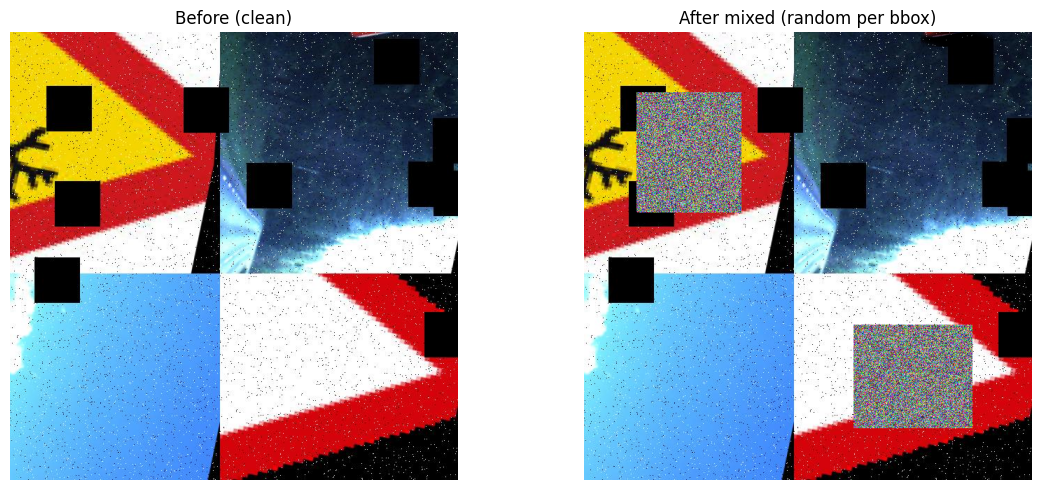

Sample: ce85c1d8-a19-5_jpg.rf.698cf2f89fdcb3b392cff2665193897e.jpg (3 box(es))


In [7]:

import matplotlib.pyplot as plt


def _preview_parse_label_file(label_path):
    class_ids, bboxes = [], []
    if not os.path.exists(label_path):
        return class_ids, bboxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_ids.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:5]])
    return class_ids, bboxes


train_images_src = os.path.join(BASE_PATH, 'train', 'images')
train_labels_src = os.path.join(BASE_PATH, 'train', 'labels')

all_names = [f for f in os.listdir(train_images_src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42)
random.shuffle(all_names)
img_name = None
bboxes = []
for name in all_names:
    stem = name.rsplit('.', 1)[0]
    _, bboxes = _preview_parse_label_file(os.path.join(train_labels_src, stem + '.txt'))
    if bboxes:
        img_name = name
        break
if img_name is None:
    raise RuntimeError('No labeled training image found for preview.')

stem = img_name.rsplit('.', 1)[0]
src_img = os.path.join(train_images_src, img_name)
src_lbl = os.path.join(train_labels_src, stem + '.txt')
_, bboxes = _preview_parse_label_file(src_lbl)

img_clean = cv2.imread(src_img)
if img_clean is None:
    raise RuntimeError(f'Could not read {src_img}')

img_attacked = img_clean.copy()
for bbox in bboxes:
    img_attacked = apply_random_attack(img_attacked, bbox)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB))
axes[0].set_title('Before (clean)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_attacked, cv2.COLOR_BGR2RGB))
axes[1].set_title('After mixed (random per bbox)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample: {img_name} ({len(bboxes)} box(es))')


## Step 3 — Albumentations (same as script)


In [8]:

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.ImageCompression(quality_range=(75, 100), p=0.3),
    A.RandomShadow(p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

print('Augmentation pipeline ready.')


Augmentation pipeline ready.


## Step 4 — Build expanded training set

Same logic as `build_expanded_train_set` in the script (paths use `train/images` under `BASE_PATH`).


In [9]:

def parse_label_file(label_path):
    class_ids, bboxes = [], []
    if not os.path.exists(label_path):
        return class_ids, bboxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_ids.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:5]])
    return class_ids, bboxes


def build_expanded_train_set(base_path, train_folder, split_ratio=0.7):
    train_images_src = os.path.join(base_path, 'train', 'images')
    train_labels_src = os.path.join(base_path, 'train', 'labels')
    robust_images    = os.path.join(base_path, train_folder, 'images')
    robust_labels    = os.path.join(base_path, train_folder, 'labels')
    os.makedirs(robust_images, exist_ok=True)
    os.makedirs(robust_labels, exist_ok=True)

    all_images = [f for f in os.listdir(train_images_src) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_images)
    attack_set = set(all_images[:int(len(all_images) * split_ratio)])

    print(f"Original images      : {len(all_images)}")
    print(f"  Attacked ({int(split_ratio*100)}%)    : {len(attack_set)}")
    print(f"  Clean    ({int((1-split_ratio)*100)}%)    : {len(all_images) - len(attack_set)}")
    print(f"  + Augmented copies  : {len(all_images)}")
    print(f"  Effective total     : ~{len(all_images) * 2}")
    print(f"  Attack types        : {ATTACK_TYPES} (random per bbox)")

    skipped = 0
    for i, img_name in enumerate(all_images):
        if (i + 1) % 500 == 0:
            print(f"  Processing {i+1}/{len(all_images)}...")

        stem    = img_name.rsplit('.', 1)[0]
        src_img = os.path.join(train_images_src, img_name)
        src_lbl = os.path.join(train_labels_src, stem + '.txt')

        img = cv2.imread(src_img)
        if img is None or not os.path.exists(src_lbl):
            skipped += 1
            continue

        class_ids, bboxes = parse_label_file(src_lbl)

        if img_name in attack_set:
            for bbox in bboxes:
                img = apply_random_attack(img, bbox)

        cv2.imwrite(os.path.join(robust_images, img_name), img)
        shutil.copy(src_lbl, os.path.join(robust_labels, stem + '.txt'))

        try:
            if bboxes:
                result     = augment(image=img, bboxes=bboxes, class_labels=class_ids)
                aug_img    = result['image']
                aug_bboxes = result['bboxes']
                aug_labels = result['class_labels']
            else:
                aug_img, aug_bboxes, aug_labels = img, [], []
        except Exception:
            aug_img, aug_bboxes, aug_labels = img, bboxes, class_ids

        cv2.imwrite(os.path.join(robust_images, stem + '_aug.jpg'), aug_img)
        with open(os.path.join(robust_labels, stem + '_aug.txt'), 'w') as f:
            for cls, bbox in zip(aug_labels, aug_bboxes):
                f.write(f"{cls} {' '.join(f'{v:.6f}' for v in bbox)}\n")

    print(f"\nExpanded training set created at: {os.path.join(base_path, train_folder)}")
    if skipped:
        print(f"Skipped {skipped} images (unreadable or missing labels).")


build_expanded_train_set(BASE_PATH, TRAIN_FOLDER, SPLIT_RATIO)


Original images      : 1314
  Attacked (70%)    : 919
  Clean    (30%)    : 395
  + Augmented copies  : 1314
  Effective total     : ~2628
  Attack types        : ['tape', 'patch', 'heavy_occlusion', 'graffiti', 'illumination'] (random per bbox)
  Processing 500/1314...
  Processing 1000/1314...

Expanded training set created at: C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\train_mixed_70_30


## Step 5 — Write YAMLs (`data.yaml` names, like script)


In [10]:

import yaml

if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(f"data.yaml not found at: {DATA_YAML}")

with open(DATA_YAML, 'r') as f:
    ref = yaml.safe_load(f)
class_names = ref['names']

with open(os.path.join(BASE_PATH, ROBUST_YAML), 'w') as f:
    yaml.dump({
        'path':  BASE_PATH,
        'train': f'{TRAIN_FOLDER}/images',
        'val':   'valid/images',
        'test':  'valid/images',
        'nc':    ref.get('nc', 264),
        'names': class_names,
    }, f)
print(f'Written: {ROBUST_YAML}')

with open(os.path.join(BASE_PATH, ATTACK_YAML), 'w') as f:
    yaml.dump({
        'path':  BASE_PATH,
        'train': f'{TRAIN_FOLDER}/images',
        'val':   'attacked_val/images',
        'test':  'attacked_val/images',
        'nc':    ref.get('nc', 264),
        'names': class_names,
    }, f)
print(f'Written: {ATTACK_YAML}')


Written: robust_mixed_70_30.yaml
Written: attack_mixed_70_30.yaml


## Step 6 — Train (Ultralytics; script-aligned: `lr0`, `mosaic`, `mixup`, `device=0`, `workers=2`)


In [11]:

from ultralytics import YOLO

if not os.path.exists(BASE_MODEL_PT):
    raise FileNotFoundError(f"Base model not found at: {BASE_MODEL_PT}")

model = YOLO(BASE_MODEL_PT)

model.train(
    data=os.path.join(BASE_PATH, ROBUST_YAML),
    epochs=EPOCHS,
    imgsz=640,
    batch=BATCH,
    lr0=0.001,
    mosaic=0.5,
    mixup=0.05,
    device=0,
    project=RUNS_DIR,
    name=RUN_NAME,
    workers=2,
)

TRAINED_MODEL_PT = os.path.join(RUNS_DIR, RUN_NAME, 'weights', 'best.pt')
print(f'Training done. Weights: {TRAINED_MODEL_PT}')


New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.13.5 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\robust_mixed_70_30.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=C:\U

## Step 7 — Build attacked validation set


In [12]:

def create_attacked_val_set(base_path):
    val_images_src = os.path.join(base_path, 'valid', 'images')
    val_labels_src = os.path.join(base_path, 'valid', 'labels')
    attacked_root  = os.path.join(base_path, 'attacked_val')

    if os.path.exists(attacked_root):
        shutil.rmtree(attacked_root)
    os.makedirs(os.path.join(attacked_root, 'images'), exist_ok=True)
    os.makedirs(os.path.join(attacked_root, 'labels'), exist_ok=True)

    all_images = [f for f in os.listdir(val_images_src) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Attacking {len(all_images)} validation images with random mixed attacks...")

    for img_name in all_images:
        img      = cv2.imread(os.path.join(val_images_src, img_name))
        stem     = img_name.rsplit('.', 1)[0]
        src_lbl  = os.path.join(val_labels_src, stem + '.txt')
        dst_lbl  = os.path.join(attacked_root, 'labels', stem + '.txt')

        if os.path.exists(src_lbl):
            shutil.copy2(src_lbl, dst_lbl)
            _, bboxes = parse_label_file(src_lbl)
            for bbox in bboxes:
                img = apply_random_attack(img, bbox)

        cv2.imwrite(os.path.join(attacked_root, 'images', img_name), img)

    print(f'Attacked validation set created at {attacked_root}')


create_attacked_val_set(BASE_PATH)


Attacking 39 validation images with random mixed attacks...
Attacked validation set created at C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\attacked_val


## Step 8 — Evaluate (clean vs mixed attack val)


In [13]:

if not os.path.exists(TRAINED_MODEL_PT):
    raise FileNotFoundError(f"Trained model not found at: {TRAINED_MODEL_PT}")

robust_model = YOLO(TRAINED_MODEL_PT)

print('--- CLEAN VALIDATION DATA ---')
clean_results = robust_model.val(data=os.path.join(BASE_PATH, ROBUST_YAML))

print('\n--- MIXED ATTACK VALIDATION DATA ---')
attack_results = robust_model.val(data=os.path.join(BASE_PATH, ATTACK_YAML))

print('\n' + '='*65)
print(f"{'Metric':<20} {'Clean Val':>18} {'Mixed Attack':>18}")
print('-' * 65)
for label, key in zip(
    ['mAP50', 'mAP50-95', 'Precision', 'Recall'],
    ['metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)'],
):
    c = clean_results.results_dict.get(key, float('nan'))
    a = attack_results.results_dict.get(key, float('nan'))
    print(f"{label:<20} {c:>18.4f} {a:>18.4f}")
print('=' * 65)


--- CLEAN VALIDATION DATA ---
Ultralytics 8.4.33  Python-3.13.5 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
Model summary (fused): 73 layers, 3,390,416 parameters, 0 gradients, 9.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 585.3215.2 MB/s, size: 42.7 KB)
val: Scanning C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\valid\labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 27.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.1s0.6ss
                   all         39         74      0.579      0.489      0.654      0.576
                     1          1          1      0.356          1      0.995      0.895
                   108          1          1          1          0      0.497      0.398
                   121          1          2          1          0      0.258      0.258
                   122          1          1       

## Step 9 — Model path / Colab download


In [14]:

if os.path.exists('/content'):
    from google.colab import files
    files.download(TRAINED_MODEL_PT)
else:
    print(f'Trained model path: {TRAINED_MODEL_PT}')


Trained model path: C:\Users\Karim\Desktop\Road-Sign-Detection-Model\runs\yolov8_mixed_70_30\weights\best.pt
